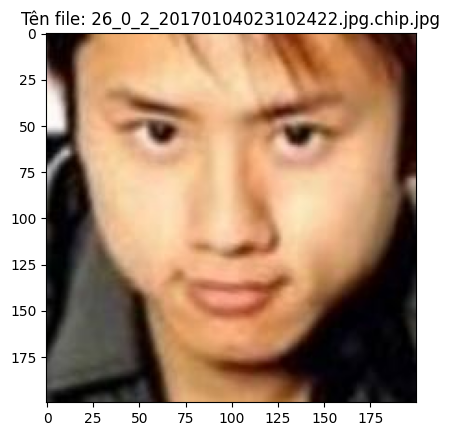

In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Thay đổi tên folder nếu cần (kiểm tra ở cột Input bên phải)
data_path ='/kaggle/input/datasets/jangedoo/utkface-new/UTKFace'

# Lấy thử 1 tên file
sample_file = os.listdir(data_path)[0]
img_path = os.path.join(data_path, sample_file)

# Hiển thị ảnh
img = Image.open(img_path)
plt.imshow(img)
plt.title(f"Tên file: {sample_file}")
plt.show()

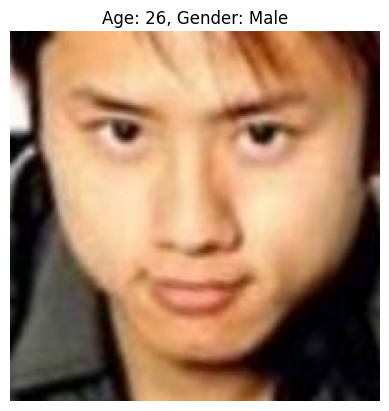

File: 26_0_2_20170104023102422.jpg.chip.jpg
Age: 26
Gender: Male


In [2]:
import os, cv2, random
file_list = [os.path.join(data_path, f) for f in os.listdir(data_path) if f.lower().endswith(".jpg")]

parts = os.path.basename(sample_file).split("_")
age = int(parts[0])
gender = "Male" if int(parts[1]) == 0 else "Female"

plt.imshow(img)
plt.title(f"Age: {age}, Gender: {gender}")
plt.axis('off')
plt.show()

print(f"File: {os.path.basename(sample_file)}")
print(f"Age: {age}")
print(f"Gender: {gender}")


Tổng số ảnh: 23708
Số nam   : 12391
Số nữ    : 11317


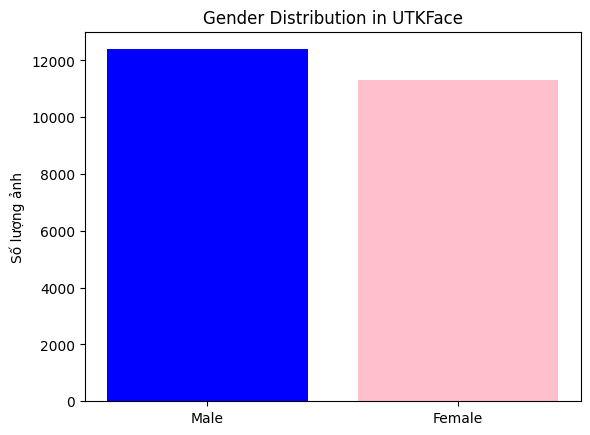

In [3]:

male_count = 0
female_count = 0

for filename in os.listdir(data_path):
    if filename.endswith(".jpg"):
        try:
            gender = int(filename.split("_")[1])
            if gender == 0:
                male_count += 1
            elif gender == 1:
                female_count += 1
        except:
            continue
print(f"Tổng số ảnh: {male_count + female_count}")
print(f"Số nam   : {male_count}")
print(f"Số nữ    : {female_count}")

labels = ['Male', 'Female']
counts = [male_count, female_count]

plt.bar(labels, counts, color=['blue', 'pink'])
plt.title("Gender Distribution in UTKFace")
plt.ylabel("Số lượng ảnh")
plt.show()

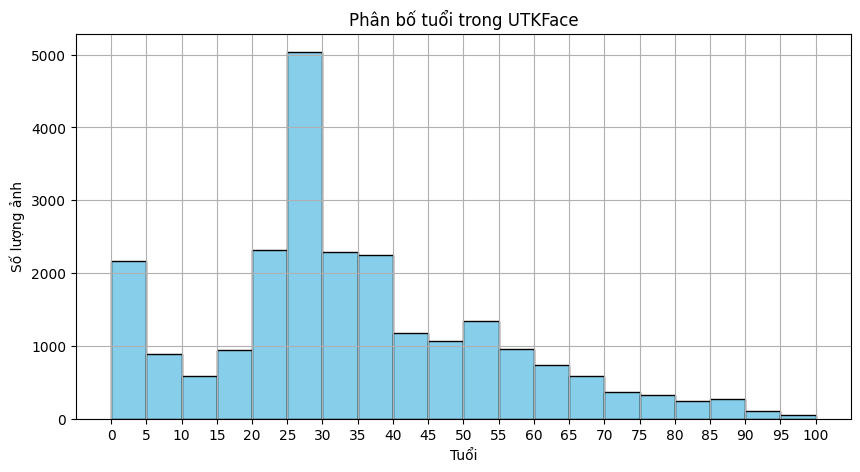

In [5]:
ages = []

for filename in os.listdir(data_path):
    if filename.endswith(".jpg"):
        try:
            age = int(filename.split("_")[0])
            ages.append(age)
        except:
            continue  # bỏ qua file lỗi

plt.figure(figsize=(10, 5))
plt.hist(ages, bins=range(0, 101, 5), color='skyblue', edgecolor='black')
plt.title("Phân bố tuổi trong UTKFace")
plt.xlabel("Tuổi")
plt.ylabel("Số lượng ảnh")
plt.grid(True)
plt.xticks(range(0, 101, 5))
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
train_files, temp_files = train_test_split(file_list, test_size=0.3, random_state=42)

val_files, test_files = train_test_split(temp_files, test_size=0.5, random_state=42)

print(f"Tổng ảnh     : {len(file_list)}")
print(f"Train ảnh    : {len(train_files)}")
print(f"Validation ảnh: {len(val_files)}")
print(f"Test ảnh     : {len(test_files)}")

Tổng ảnh     : 23708
Train ảnh    : 16595
Validation ảnh: 3556
Test ảnh     : 3557


In [24]:
import tensorflow as tf

MAX_AGE = 116

def extract_labels_from_filename(file_path):
    base = tf.strings.split(file_path, os.sep)[-1]
    parts = tf.strings.split(base, '_')
    age = tf.strings.to_number(parts[0], out_type=tf.float32) / MAX_AGE
    gender = tf.strings.to_number(parts[1], out_type=tf.float32)
    return gender, age
    
#Hàm load ảnh thực hiện: nén ảnh sang RBG, resize ảnh về 128x128,chia các pixel ảnh với 255 
#-> thành mảng trong khoảng [0,1]
def load_and_preprocess(file_path, img_size=128):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [img_size, img_size])
    img = tf.cast(img, tf.float32) 
    gender, age = extract_labels_from_filename(file_path)
    return img, {'gender_output': gender, 'age_output': age}
    
#Hàm biến đổi ảnh thành những tấm ảnh lật, xoay, phóng to, thu nhỏ ...
def augment(img, labels):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    img = tf.image.random_saturation(img, lower=0.9, upper=1.1)
    img = tf.image.random_hue(img, max_delta=0.02)
    return img, labels

def create_dataset(file_list, batch_size=64, augment_data=False, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices(file_list)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(file_list))
    ds = ds.map(lambda x: load_and_preprocess(x, 128), num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

#Tập dữ liệu gốc để train
train_gen = create_dataset(train_files, batch_size=64, augment_data=True, shuffle=True)
#Tập dữ liệu đã được biến đổi như xoay , lât, phóng to, thu nhỏ để train 
val_gen = create_dataset(val_files, batch_size=64, augment_data=False, shuffle=False)

In [25]:
# Lấy thử 1 batch (64 ảnh) ra để xem
for images, labels in train_gen.take(1):
    print("✅ Dữ liệu đã được nạp thành công.")
    print(f"Kiểu dữ liệu của ảnh: {images.dtype}")
    print(f"Kích thước batch: {images.shape}") # Sẽ hiện (64, 128, 128, 3)

✅ Dữ liệu đã được nạp thành công.
Kiểu dữ liệu của ảnh: <dtype: 'float32'>
Kích thước batch: (64, 128, 128, 3)


In [26]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import pandas as pd
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50, VGG16, EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping
# Import hàm sơ chế dành riêng cho ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

# Import hàm sơ chế dành riêng cho EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess

In [28]:
def build_model(base_model_class, preprocess_func, pooling_mode='avg', input_size=128):
    inputs = layers.Input(shape=(input_size, input_size, 3), name="input")
    
    # Preprocessing
    x = preprocess_func(inputs)
    
    # Base model (frozen ở phase 1)
    base_model = base_model_class(
        include_top=False,
        pooling=pooling_mode,
        weights='imagenet',
        input_shape=(input_size, input_size, 3)
    )
    base_model.trainable = False
    
    x = base_model(x, training = False)
    
    # Head cải tiến (shared features + BatchNorm)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    
    # Gender branch
    gender = layers.Dense(128, activation='relu')(x)
    gender = layers.Dropout(0.2)(gender)
    gender_output = layers.Dense(1, activation='sigmoid', name='gender_output')(gender)
    
    # Age branch
    age = layers.Dense(128, activation='relu')(x)
    age = layers.Dropout(0.2)(age)
    age_output = layers.Dense(1, activation='linear', name='age_output')(age)
    
    model = Model(inputs=inputs, outputs=[gender_output, age_output])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss={
            'gender_output': 'binary_crossentropy',
            'age_output': 'huber'           # Huber ổn định và tốt hơn MSE
        },
        loss_weights={
            'gender_output': 1.0,
            'age_output': 0.3             
        },
        metrics={
            'gender_output': 'accuracy',
            'age_output': 'mae'
        }
    )
    return model, base_model   # Trả thêm base_model để fine-tuning
def train_and_save(model, base_model, name, train_gen, val_gen, output_dir="/kaggle/working"):
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
        ModelCheckpoint(
            filepath=f"{output_dir}/{name}_best.keras",
            monitor='val_gender_output_accuracy',
            mode='max',
            save_best_only=True,
            verbose=1
        )
    ]
    
    # ================= PHASE 1: Train head only =================
    print(f"🔥 Bắt đầu PHASE 1 - Training head (backbone frozen) cho {name}")
    history1 = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=30,
        callbacks=callbacks,
        verbose=1
    )
    
    # ================= PHASE 2: Fine-tuning =================
    print(f"\n🔥 Bắt đầu PHASE 2 - Fine-tuning cho {name}")
    base_model.trainable = True
    
    # Chỉ mở 40 layer cuối (bạn có thể thử thay đổi số này nếu muốn)
    for layer in base_model.layers[:-40]:
        layer.trainable = False
    
    # Compile lại với learning rate nhỏ - PHẢI hard-code lại loss & loss_weights
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
        loss={
            'gender_output': 'binary_crossentropy',
            'age_output': 'huber'
        },
        loss_weights={
            'gender_output': 1.0,
            'age_output': 0.3
        },
        metrics={
            'gender_output': 'accuracy',
            'age_output': 'mae'
        }
    )
    
    history2 = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=15,
        callbacks=callbacks,
        verbose=1
    )
    
    # Lưu kết quả
    pd.DataFrame(history1.history).to_csv(f"{output_dir}/{name}_phase1_history.csv", index=False)
    pd.DataFrame(history2.history).to_csv(f"{output_dir}/{name}_phase2_history.csv", index=False)
    model.save(f"{output_dir}/{name}_final_model.keras")
    
    print(f"✅ Hoàn thành training {name}! Model & history đã lưu.")
    return model


In [30]:
model_eff, base_eff = build_model(
    base_model_class=EfficientNetB0,
    preprocess_func=eff_preprocess,
    pooling_mode='avg',
    input_size=128
)

train_and_save(
    model_eff, base_eff,
    name="EfficientNetB0_128",
    train_gen=train_gen,
    val_gen=val_gen
)

del model_eff
del base_eff
tf.keras.backend.clear_session()
import gc
gc.collect()

model_res, base_res = build_model(
    base_model_class=ResNet50,
    preprocess_func=resnet_preprocess,
    pooling_mode='avg',
    input_size=128
)

train_and_save(
    model_res, base_res,
    name="ResNet50_128",
    train_gen=train_gen,
    val_gen=val_gen
)

🔥 Bắt đầu PHASE 1 - Training head (backbone frozen) cho EfficientNetB0_128
Epoch 1/30


2026-03-31 04:50:48.810920: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 04:50:48.947581: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 04:50:49.239664: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 04:50:49.381355: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 04:50:49.523303: E external/local_xla/xla/stream_

259/260 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - age_output_loss: 0.1753 - age_output_mae: 0.4389 - gender_output_accuracy: 0.7958 - gender_output_loss: 0.4434 - loss: 0.4785

2026-03-31 04:51:18.746434: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 04:51:18.880362: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 04:51:19.160901: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 04:51:19.302895: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 04:51:20.089561: E external/local_xla/xla/stream_

260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - age_output_loss: 0.1749 - age_output_mae: 0.4383 - gender_output_accuracy: 0.7959 - gender_output_loss: 0.4432 - loss: 0.4782

2026-03-31 04:51:42.032056: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 04:51:42.166607: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 04:51:42.446499: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 04:51:42.588744: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 04:51:43.349478: E external/local_xla/xla/stream_


Epoch 1: val_gender_output_accuracy improved from -inf to 0.86783, saving model to /kaggle/working/EfficientNetB0_128_best.keras
260/260 ━━━━━━━━━━━━━━━━━━━━ 79s 191ms/step - age_output_loss: 0.1746 - age_output_mae: 0.4376 - gender_output_accuracy: 0.7960 - gender_output_loss: 0.4430 - loss: 0.4779 - val_age_output_loss: 0.0162 - val_age_output_mae: 0.1338 - val_gender_output_accuracy: 0.8678 - val_gender_output_loss: 0.3083 - val_loss: 0.3121 - learning_rate: 0.0010
Epoch 2/30
258/260 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - age_output_loss: 0.0140 - age_output_mae: 0.1268 - gender_output_accuracy: 0.8579 - gender_output_loss: 0.3291 - loss: 0.3319
Epoch 2: val_gender_output_accuracy improved from 0.86783 to 0.88076, saving model to /kaggle/working/EfficientNetB0_128_best.keras
260/260 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - age_output_loss: 0.0140 - age_output_mae: 0.1267 - gender_output_accuracy: 0.8579 - gender_output_loss: 0.3291 - loss: 0.3319 - val_age_output_loss: 0.0077 - val_age_ou

<Functional name=functional, built=True>

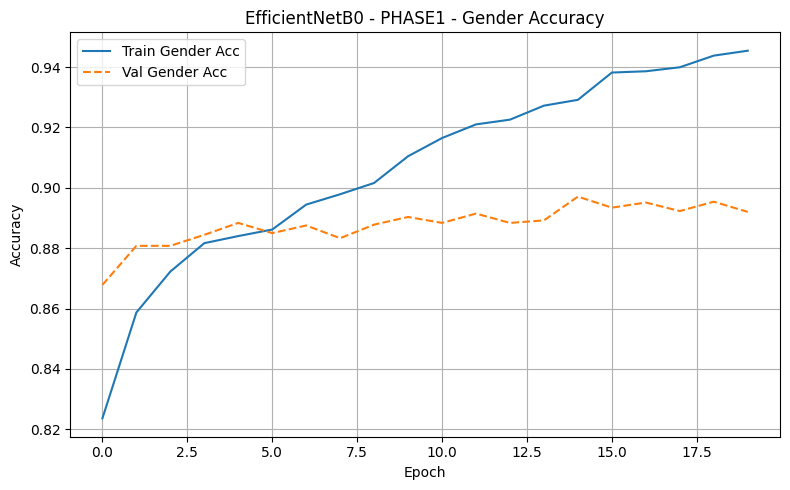

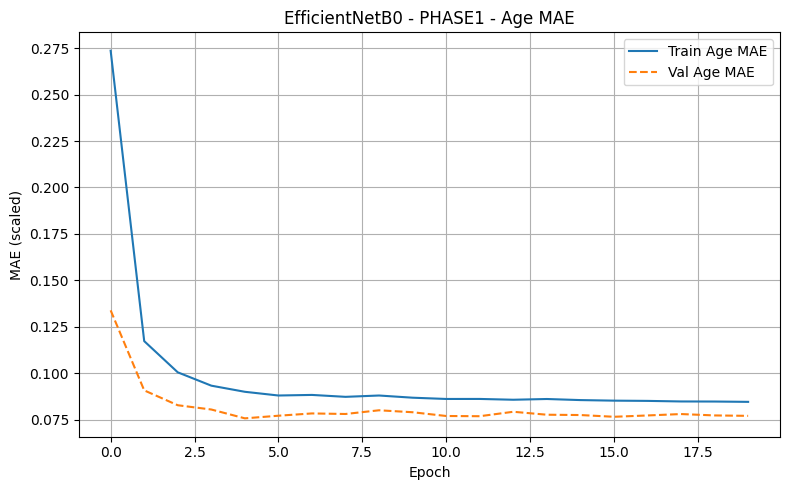

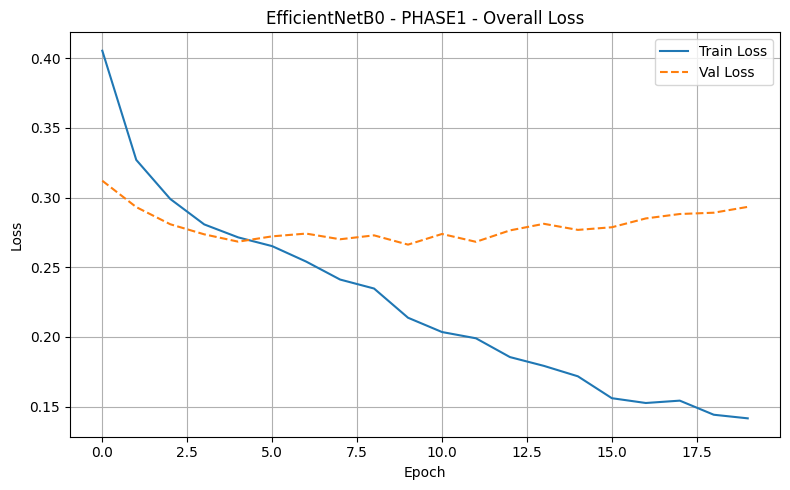

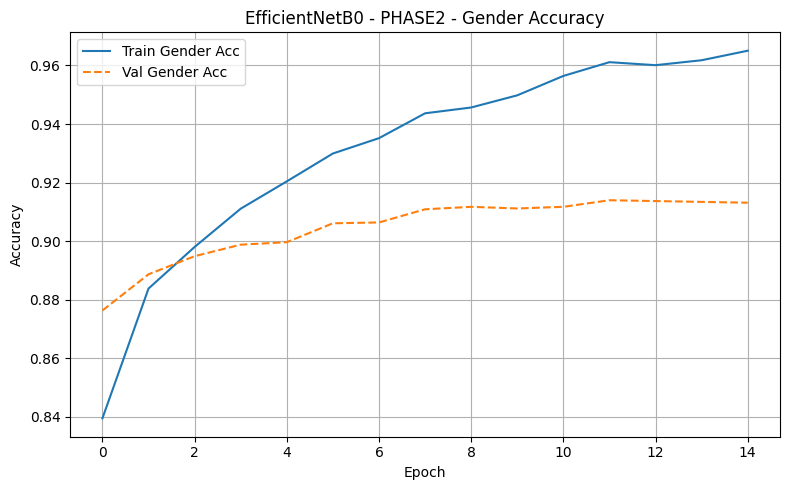

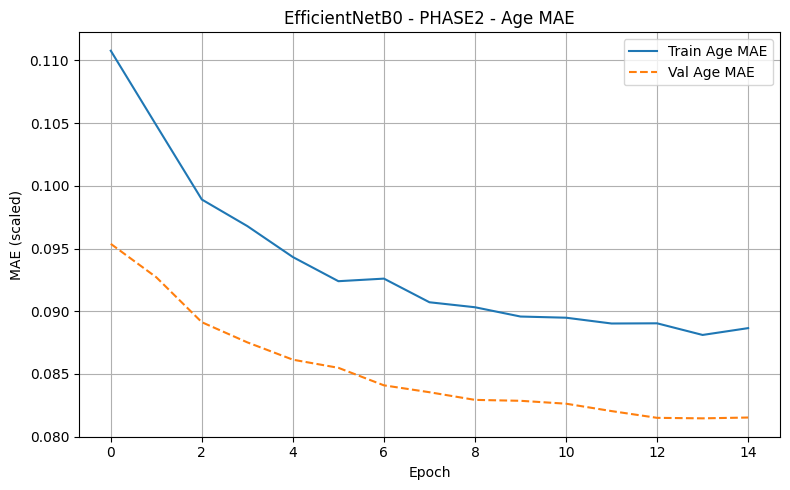

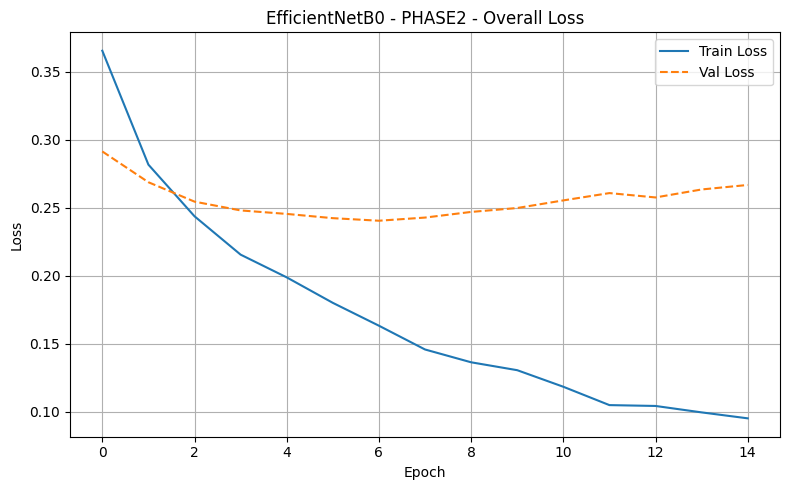

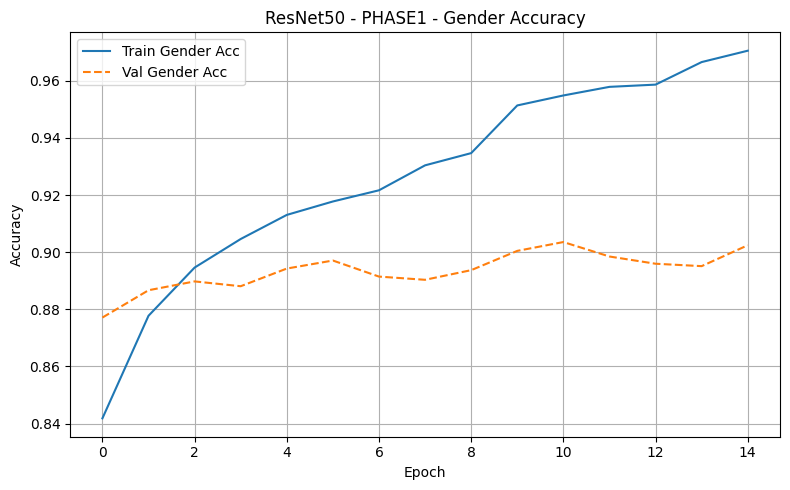

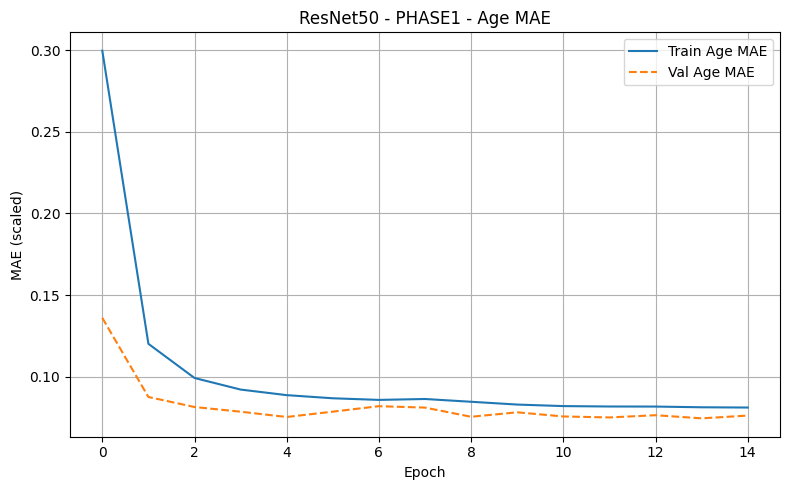

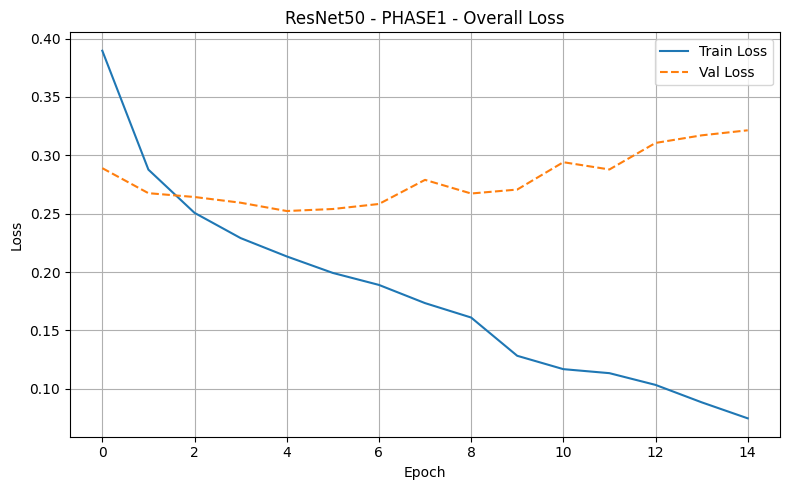

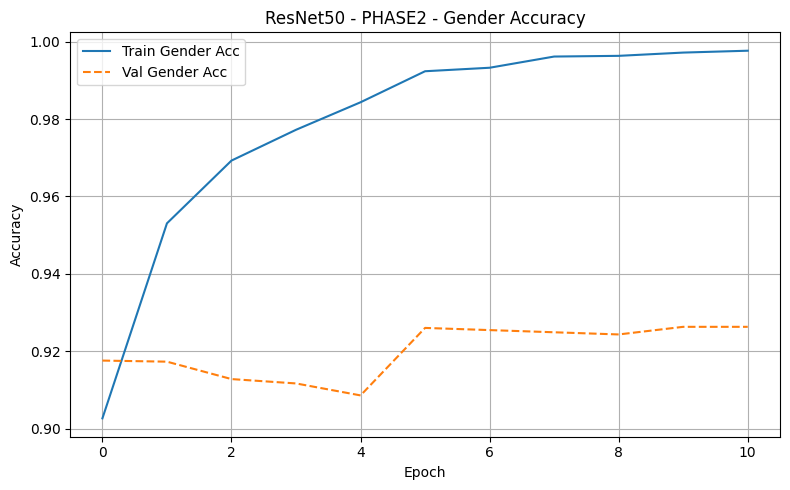

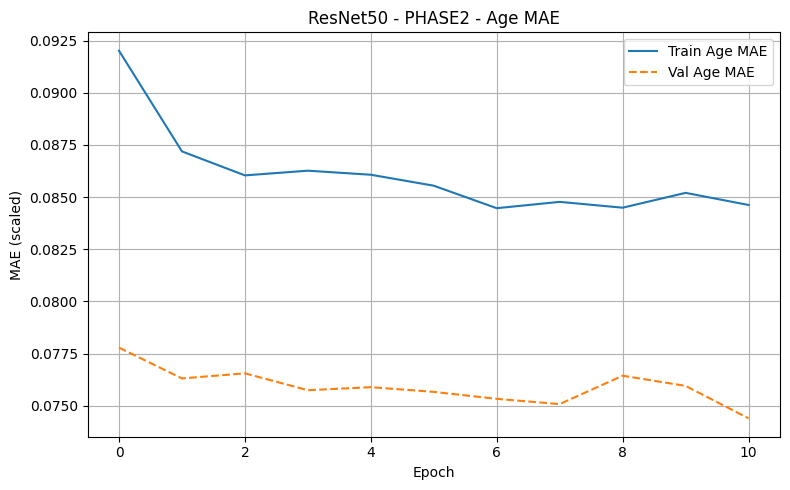

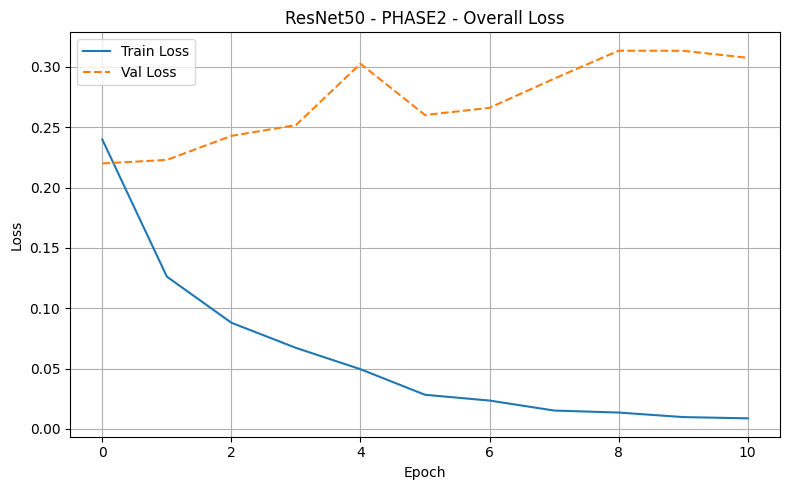

✅ Đã lưu tất cả biểu đồ vào thư mục: ./plots


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import os

models = {
    "EfficientNetB0": {
        "phase1": "/kaggle/working/EfficientNetB0_128_phase1_history.csv",
        "phase2": "/kaggle/working/EfficientNetB0_128_phase2_history.csv"
    },
    "ResNet50": {
        "phase1": "/kaggle/working/ResNet50_224_phase1_history.csv",
        "phase2": "/kaggle/working/ResNet50_224_phase2_history.csv"
    }
}

save_dir = "./plots"
os.makedirs(save_dir, exist_ok=True)

for model_name, paths in models.items():
    for phase_name, path in paths.items():
        if not os.path.exists(path):
            print(f"Không tìm thấy file {path}. Bỏ qua {model_name} - {phase_name}.")
            continue

        df = pd.read_csv(path)

        # ===== 1. Gender Accuracy =====
        plt.figure(figsize=(8, 5))
        plt.plot(df['gender_output_accuracy'], label='Train Gender Acc')
        plt.plot(df['val_gender_output_accuracy'], linestyle='--', label='Val Gender Acc')
        plt.title(f'{model_name} - {phase_name.upper()} - Gender Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, f"{model_name}_{phase_name}_gender_accuracy.png"))
        plt.show()

        # ===== 2. Age MAE =====
        plt.figure(figsize=(8, 5))
        plt.plot(df['age_output_mae'], label='Train Age MAE')
        plt.plot(df['val_age_output_mae'], linestyle='--', label='Val Age MAE')
        plt.title(f'{model_name} - {phase_name.upper()} - Age MAE')
        plt.xlabel('Epoch')
        plt.ylabel('MAE (scaled)')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, f"{model_name}_{phase_name}_age_mae.png"))
        plt.show()

        # ===== 3. Overall Loss =====
        plt.figure(figsize=(8, 5))
        plt.plot(df['loss'], label='Train Loss')
        plt.plot(df['val_loss'], linestyle='--', label='Val Loss')
        plt.title(f'{model_name} - {phase_name.upper()} - Overall Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, f"{model_name}_{phase_name}_overall_loss.png"))
        plt.show()

print(f"✅ Đã lưu tất cả biểu đồ vào thư mục: {save_dir}")

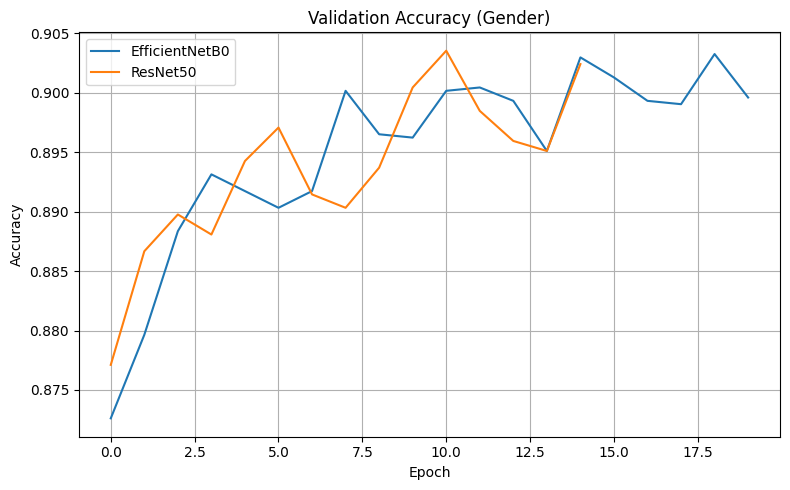

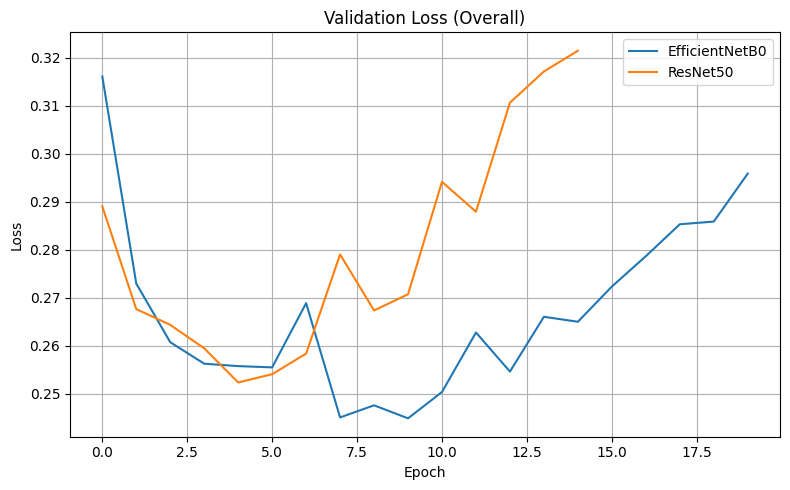

✅ Đã lưu các biểu đồ so sánh vào thư mục: ./plots_compare


In [33]:
save_dir_compare = "./plots_compare"
os.makedirs(save_dir_compare, exist_ok=True)

# Đọc toàn bộ lịch sử vào bộ nhớ
histories = {}
for name, path in files.items():
    if os.path.exists(path):
        histories[name] = pd.read_csv(path)

# ==== So sánh Validation Accuracy (Giới tính) ====
plt.figure(figsize=(8, 5))
for name, df in histories.items():
    plt.plot(df['val_gender_output_accuracy'], label=name)
plt.title("Validation Accuracy (Gender)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(save_dir_compare, "val_accuracy.png"))
plt.show()

# ==== So sánh Validation Loss (Tổng thể) ====
plt.figure(figsize=(8, 5))
for name, df in histories.items():
    plt.plot(df['val_loss'], label=name)
plt.title("Validation Loss (Overall)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(save_dir_compare, "val_loss.png"))
plt.show()

print(f"✅ Đã lưu các biểu đồ so sánh vào thư mục: {save_dir_compare}")

In [34]:
import os
import tensorflow as tf

model_paths = {
    "EfficientNetB0": "/kaggle/working/EfficientNetB0_128_final_model.keras",
    "ResNet50": "/kaggle/working/ResNet50_128_final_model.keras"
}

# Tạo tập test
test_gen = create_dataset(test_files, batch_size=64, augment_data=False, shuffle=False)

for name, model_path in model_paths.items():
    if not os.path.exists(model_path):
        print(f"⚠️ Không tìm thấy model {model_path}. Bỏ qua {name}.")
        continue

    print(f"\n🔍 Đang đánh giá {name} trên tập test...")

    try:
        model = tf.keras.models.load_model(model_path)
    except Exception as e:
        print(f"Load thường bị lỗi: {e}")
        print("Thử load lại với custom_objects...")

        model = tf.keras.models.load_model(
            model_path,
            custom_objects={
                "Huber": tf.keras.losses.Huber,
                "mae": tf.keras.metrics.MeanAbsoluteError
            }
        )

    results = model.evaluate(test_gen, verbose=1, return_dict=True)

    print(f"Kết quả của {name}:")
    for metric_name, value in results.items():
        print(f"   - {metric_name}: {value:.4f}")


🔍 Đang đánh giá EfficientNetB0 trên tập test...
55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - age_output_loss: 0.0067 - age_output_mae: 0.0860 - gender_output_accuracy: 0.8985 - gender_output_loss: 0.2482 - loss: 0.2495

2026-03-31 05:14:55.397448: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 05:14:55.532576: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 05:14:55.813682: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 05:14:55.955400: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 05:14:56.701907: E external/local_xla/xla/stream_

56/56 ━━━━━━━━━━━━━━━━━━━━ 20s 206ms/step - age_output_loss: 0.0067 - age_output_mae: 0.0860 - gender_output_accuracy: 0.8984 - gender_output_loss: 0.2483 - loss: 0.2496
Kết quả của EfficientNetB0:
   - age_output_loss: 0.0066
   - age_output_mae: 0.0847
   - gender_output_accuracy: 0.8974
   - gender_output_loss: 0.2526
   - loss: 0.2526

🔍 Đang đánh giá ResNet50 trên tập test...
56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - age_output_loss: 0.0067 - age_output_mae: 0.0850 - gender_output_accuracy: 0.9047 - gender_output_loss: 0.2217 - loss: 0.2229
Kết quả của ResNet50:
   - age_output_loss: 0.0066
   - age_output_mae: 0.0847
   - gender_output_accuracy: 0.9050
   - gender_output_loss: 0.2324
   - loss: 0.2309
